# **OBJECTIVE**

Forecast short-term household energy usage using past time-series data.

Household Power Consumption Dataset
Contains minute-level measurements of active power usage and other household metrics over time.

# importing liabraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt

**uploading the dataset**

In [12]:
from google.colab import files
uploaded = files.upload()

Saving household_power_consumption.csv to household_power_consumption (2).csv


In [13]:
df = pd.read_csv('household_power_consumption.csv')
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


In [14]:
#combining date and time column
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format="%d/%m/%Y %H:%M:%S")

In [15]:
#setting date and time as index
df.set_index('datetime', inplace=True)

**EDA**

In [16]:
print(df.isnull())

                      Date   Time  Global_active_power  Global_reactive_power  \
datetime                                                                        
2006-12-16 17:24:00  False  False                False                  False   
2006-12-16 17:25:00  False  False                False                  False   
2006-12-16 17:26:00  False  False                False                  False   
2006-12-16 17:27:00  False  False                False                  False   
2006-12-16 17:28:00  False  False                False                  False   
...                    ...    ...                  ...                    ...   
2008-12-13 21:34:00  False  False                False                  False   
2008-12-13 21:35:00  False  False                False                  False   
2008-12-13 21:36:00  False  False                False                  False   
2008-12-13 21:37:00  False  False                False                  False   
2008-12-13 21:38:00  False  

In [17]:
#converting column to numeric
cols_to_numeric = df.columns.drop(['Date', 'Time'], errors='ignore')
df[cols_to_numeric] = df[cols_to_numeric].apply(pd.to_numeric, errors='coerce')

In [18]:
#dropping the missing values
df.dropna(inplace=True)

**changing into hourly**

In [19]:
df_hourly = df['Global_active_power'].resample('H').mean()

/tmp/ipython-input-19-3177786709.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df['Global_active_power'].resample('H').mean()


In [20]:
#printing data in hours
print(df_hourly.head())

datetime
2006-12-16 17:00:00    4.222889
2006-12-16 18:00:00    3.632200
2006-12-16 19:00:00    3.400233
2006-12-16 20:00:00    3.268567
2006-12-16 21:00:00    3.056467
Freq: h, Name: Global_active_power, dtype: float64


**FEATTURE ENGINEERING**

In [21]:
#converting resampled in a data frame
df_feat=df_hourly.to_frame(name='Global_active_power')

In [22]:
df_feat.dropna(inplace=True)

In [23]:
#changing features according to need
df_feat['hour'] = df_feat.index.hour
df_feat['dayofweek'] = df_feat.index.dayofweek
df_feat['is_weekend'] = df_feat['dayofweek'].isin([5, 6]).astype(int)

In [24]:
print(df_feat.head())

                     Global_active_power  hour  dayofweek  is_weekend
datetime                                                             
2006-12-16 17:00:00             4.222889    17          5           1
2006-12-16 18:00:00             3.632200    18          5           1
2006-12-16 19:00:00             3.400233    19          5           1
2006-12-16 20:00:00             3.268567    20          5           1
2006-12-16 21:00:00             3.056467    21          5           1


# ARIMA FORECAST

In [25]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error , mean_squared_error
import numpy as np

In [27]:
train = df_hourly.iloc[:-24*7]
test = df_hourly.iloc[-24*7:]

In [28]:
#training the arima model
model = ARIMA(train, order=(2, 1, 2))
model_fit = model.fit()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [29]:
#forcasting
forecast_arima = model_fit.forecast(steps=len(test))


In [30]:
#evaluating
mae_arima = mean_absolute_error(test, forecast_arima)
rmse_arima = np.sqrt(mean_squared_error(test, forecast_arima))

In [31]:
print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)

ARIMA MAE: 0.7571768307917675
ARIMA RMSE: 0.9245387602218414


# FORCASTING USING  PROPHET


In [32]:
from prophet import Prophet

In [33]:
#arrainging the data
prophet_df = df_hourly.reset_index().rename(columns={'datetime': 'ds', 'Global_active_power': 'y'})

In [34]:
#taining the model
train_prophet = prophet_df.iloc[:-24*7]
test_prophet = prophet_df.iloc[-24*7:]

In [35]:
#fitting the values init
model = Prophet()
model.fit(train_prophet)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpiv02r7rt/e3o_dbt4.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpiv02r7rt/z260_bb3.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=55270', 'data', 'file=/tmp/tmpiv02r7rt/e3o_dbt4.json', 'init=/tmp/tmpiv02r7rt/z260_bb3.json', 'output', 'file=/tmp/tmpiv02r7rt/prophet_modelz89imy8v/prophet_model-20250727151025.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
15:10:25 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:10:31 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [36]:
#arrainging it in dataframe
future = model.make_future_dataframe(periods=24*7, freq='H')
forecast = model.predict(future)


/usr/local/lib/python3.11/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


In [37]:
#extracting valus that we forcasted
forecast_values = forecast[['ds', 'yhat']].set_index('ds').loc[test_prophet['ds']]


In [38]:
#evaluating them
mae_prophet = mean_absolute_error(test_prophet['y'], forecast_values['yhat'])
rmse_prophet = np.sqrt(mean_squared_error(test_prophet['y'], forecast_values['yhat']))

In [39]:
print("Prophet MAE:", mae_prophet)
print("Prophet RMSE:", rmse_prophet)

Prophet MAE: 0.5609411527123543
Prophet RMSE: 0.730759673376798


# FORCASTING USING XGBOOST

In [40]:
from xgboost import XGBRegressor
df_feat['lag1'] = df_feat['Global_active_power'].shift(1)
df_feat['lag2'] = df_feat['Global_active_power'].shift(2)
df_feat.dropna(inplace=True)

In [41]:
#train test split
train_xgb = df_feat.iloc[:-24*7]
test_xgb = df_feat.iloc[-24*7:]

X_train = train_xgb.drop('Global_active_power', axis=1)
y_train = train_xgb['Global_active_power']

X_test = test_xgb.drop('Global_active_power', axis=1)
y_test = test_xgb['Global_active_power']

In [42]:
#fitting tthe model
model = XGBRegressor()
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [43]:
#pridecting using xgb
y_pred_xgb = model.predict(X_test)


In [44]:
#evaluating
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))


In [45]:
print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)

XGBoost MAE: 0.42652487697987046
XGBoost RMSE: 0.6053450791141839


# **VISUALIZATION**

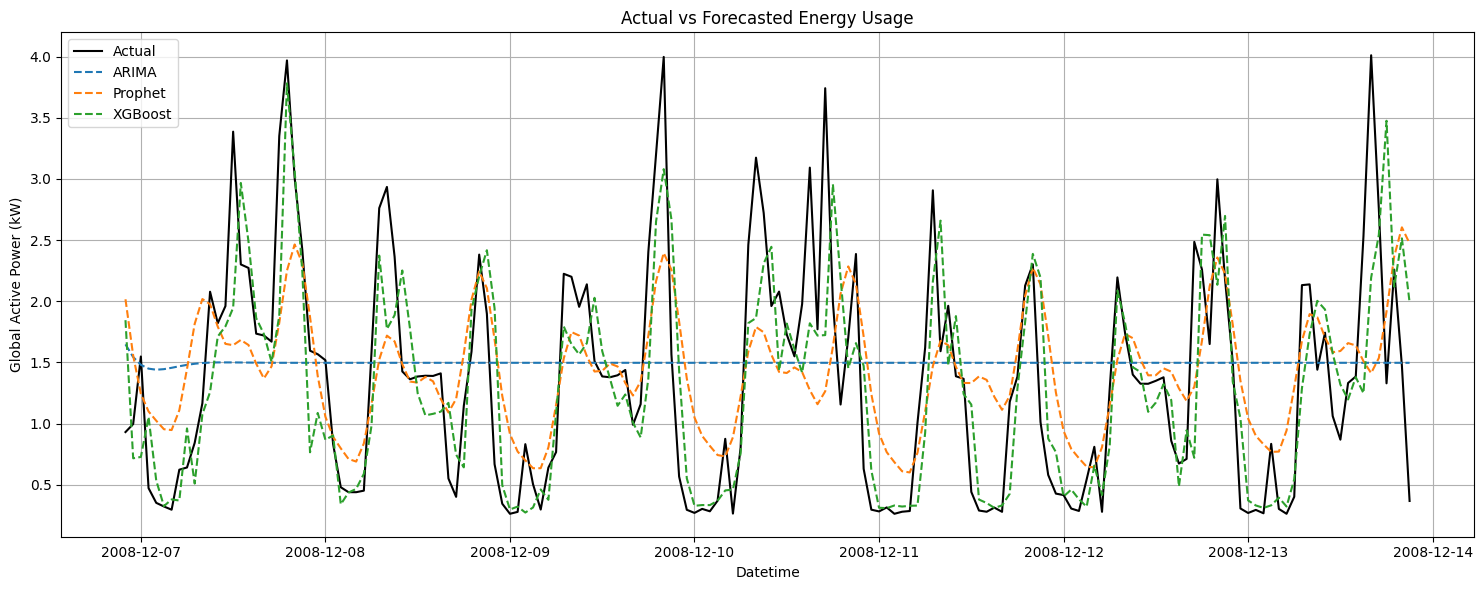

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.plot(test.index, test.values, label="Actual", color='black')
plt.plot(test.index, forecast_arima, label="ARIMA", linestyle='--')
plt.plot(test_prophet['ds'], forecast_values['yhat'], label="Prophet", linestyle='--')
plt.plot(test.index, y_pred_xgb, label="XGBoost", linestyle='--')
plt.legend()
plt.title("Actual vs Forecasted Energy Usage")
plt.xlabel("Datetime")
plt.ylabel("Global Active Power (kW)")
plt.grid(True)
plt.tight_layout()
plt.show()


**ALL MODEL PERFORMANCE**

In [48]:
print("ALL MODEL PERFORMANCE")
print(f"ARIMA   - MAE: {mae_arima:.4f}, RMSE: {rmse_arima:.4f}")
print(f"Prophet - MAE: {mae_prophet:.4f}, RMSE: {rmse_prophet:.4f}")
print(f"XGBoost - MAE: {mae_xgb:.4f}, RMSE: {rmse_xgb:.4f}")


ALL MODEL PERFORMANCE
ARIMA   - MAE: 0.7572, RMSE: 0.9245
Prophet - MAE: 0.5609, RMSE: 0.7308
XGBoost - MAE: 0.4265, RMSE: 0.6053


# **CONCLUSION**

In this project, we forecasted short-term household energy consumption using time series data. After cleaning and resampling the dataset to hourly intervals, we engineered time-based features like hour, day of the week, and weekend indicators. We applied three models—ARIMA, Prophet, and XGBoost—to predict future energy usage. Model performance was evaluated using MAE and RMSE, and actual vs. predicted usage was visualized. Overall, XGBoost gave the best results due to its ability to leverage multiple features, while ARIMA and Prophet provided useful baseline comparisons. This task improved our skills in time series forecasting, feature engineering, and model evaluation.